In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\Hiral\OneDrive\Desktop\AML_DeepLearning_Project\dataset\final_features.csv"
)

In [2]:
y = df["isFraud"]

In [3]:
X = df.drop(
    columns=["isFraud"]
)

In [4]:
X = pd.get_dummies(
    X,
    columns=["type"],
    dtype=int
)

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [7]:
print(y_train.value_counts())

isFraud
0    5083103
1       6558
Name: count, dtype: int64


In [8]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, weights)
)

print(class_weights)

{np.int64(0): np.float64(0.5006450784097823), np.int64(1): np.float64(388.0497865202806)}


In [9]:
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [10]:
model = Sequential([
    
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_scaled.shape[1],)
    ),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        16,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

c:\Users\Hiral\OneDrive\Desktop\AML_DeepLearning_Project\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [13]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=256,
    class_weight=class_weights,
    callbacks=[early_stopping]
)

Epoch 1/20
15906/15906 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - accuracy: 0.9451 - loss: 0.1618 - precision: 0.0217 - recall: 0.9404 - val_accuracy: 0.9386 - val_loss: 0.1352 - val_precision: 0.0198 - val_recall: 0.9813
Epoch 2/20
15906/15906 ━━━━━━━━━━━━━━━━━━━━ 79s 5ms/step - accuracy: 0.9540 - loss: 0.1361 - precision: 0.0263 - recall: 0.9583 - val_accuracy: 0.9658 - val_loss: 0.0791 - val_precision: 0.0335 - val_recall: 0.9370
Epoch 3/20
15906/15906 ━━━━━━━━━━━━━━━━━━━━ 64s 4ms/step - accuracy: 0.9574 - loss: 0.1294 - precision: 0.0284 - recall: 0.9613 - val_accuracy: 0.9583 - val_loss: 0.0952 - val_precision: 0.0285 - val_recall: 0.9658
Epoch 4/20
15906/15906 ━━━━━━━━━━━━━━━━━━━━ 56s 4ms/step - accuracy: 0.9585 - loss: 0.1148 - precision: 0.0293 - recall: 0.9651 - val_accuracy: 0.9653 - val_loss: 0.0836 - val_precision: 0.0336 - val_recall: 0.9557
Epoch 5/20
15906/15906 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - accuracy: 0.9628 - loss: 0.1198 - precision: 0.0324 - recall: 0.9607 - val_accura

In [14]:
results = model.evaluate(
    X_test_scaled,
    y_test
)

print(results)

39763/39763 ━━━━━━━━━━━━━━━━━━━━ 59s 1ms/step - accuracy: 0.9816 - loss: 0.0517 - precision: 0.0613 - recall: 0.9274
[0.051702823489904404, 0.9816153049468994, 0.061305154114961624, 0.9273947477340698]


In [15]:
y_probability = model.predict(
    X_test_scaled
).ravel()

39763/39763 ━━━━━━━━━━━━━━━━━━━━ 38s 944us/step


In [16]:
y_pred = (
    y_probability >= 0.5
).astype(int)

In [17]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1270777
           1       0.06      0.93      0.12      1639

    accuracy                           0.98   1272416
   macro avg       0.53      0.95      0.55   1272416
weighted avg       1.00      0.98      0.99   1272416



In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[1247503   23274]
 [    119    1520]]


In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

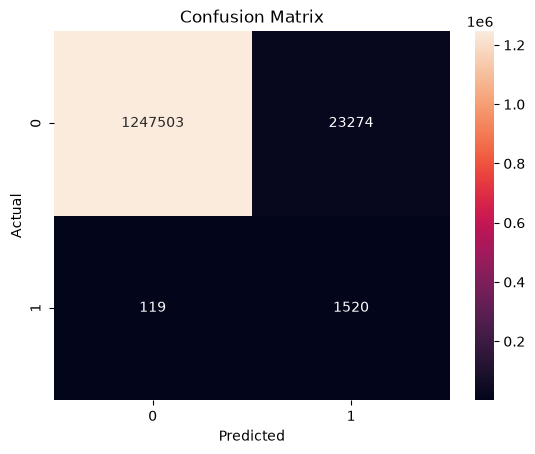

In [26]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.9946600514719799


In [28]:
model.save(
    r"C:\Users\Hiral\OneDrive\Desktop\AML_DeepLearning_Project\models\fraud_detection_model.keras"
)

In [39]:
import joblib

feature_names = X_train.columns.tolist()

joblib.dump(
    feature_names,
    r"C:\Users\Hiral\OneDrive\Desktop\AML_DeepLearning_Project\models\feature_names.pkl"
)

print("Feature names saved successfully!")

Feature names saved successfully!


In [30]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5089661, 14)
X_test shape: (1272416, 14)
y_train shape: (5089661,)
y_test shape: (1272416,)


In [31]:
print("Number of features:", X_train.shape[1])
print("Feature names:")
print(X_train.columns.tolist())

Number of features: 14
Feature names:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceChangeOrg', 'balanceChangeDest', 'amountToBalanceRatio', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


In [32]:
import os

model_path = r"C:\Users\Hiral\OneDrive\Desktop\AML_DeepLearning_Project\models\fraud_detection_model.keras"
scaler_path = r"C:\Users\Hiral\OneDrive\Desktop\AML_DeepLearning_Project\models\scaler.pkl"

print("Model exists:", os.path.exists(model_path))
print("Scaler exists:", os.path.exists(scaler_path))

Model exists: True
Scaler exists: True


In [33]:
from tensorflow.keras.models import load_model
import joblib

loaded_model = load_model(model_path)
loaded_scaler = joblib.load(scaler_path)

print("Model loaded successfully!")
print("Scaler loaded successfully!")

Model loaded successfully!
Scaler loaded successfully!


In [34]:
sample = X_test.iloc[[0]]

print(sample)

         step     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
5736793   399  405746.37            0.0             0.0       594340.93   

         newbalanceDest  balanceChangeOrg  balanceChangeDest  \
5736793       1000087.3               0.0          405746.37   

         amountToBalanceRatio  type_CASH_IN  type_CASH_OUT  type_DEBIT  \
5736793             405746.37             0              1           0   

         type_PAYMENT  type_TRANSFER  
5736793             0              0  


In [35]:
sample_scaled = loaded_scaler.transform(sample)

In [36]:
probability = loaded_model.predict(sample_scaled)[0][0]

print("Fraud probability:", probability)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
Fraud probability: 0.00030600754


In [37]:
if probability >= 0.5:
    print("Prediction: FRAUD")
else:
    print("Prediction: NORMAL")

Prediction: NORMAL
